# CN7 사출 공정 이상탐지 — Denoising Autoencoder

**목적** — 650톤 사출기의 CN7 W/S SIDE MLD'G 생산 데이터에서, **양품의 정상 공정 패턴만 학습**해
그 패턴에서 벗어난 샷을 실시간으로 골라내는 이상탐지 모델을 만듭니다.

**왜 비지도 이상탐지인가** — 전체 3,974행 중 불량이 28행(0.7%)뿐입니다.
지도학습 분류기를 학습시키기에는 불량 표본이 절대적으로 부족하므로,
양품만 학습해 "정상에서 얼마나 벗어났는가(복원 오차)"로 판정하는 방식을 씁니다.

### 전체 흐름

```
원본 데이터 → 대상 선정 → 전처리(샷 구조 파악) → 샷 단위 4분할 → 스케일링
   → DAE 학습(양품만) → 캘리브레이션셋으로 임계값 결정 → 테스트셋 1회 평가 → 진단
```

### `guidebook_progress.ipynb`에서 바뀐 점

이 노트북은 탐색 과정을 정리하면서 아래 세 가지를 고쳤습니다. 각 절에서 이유를 설명합니다.

| # | 변경 | 이유 |
|---|---|---|
| 1 | 무작위 행 분할 → **샷(TimeStamp) 단위 그룹 분할** | LH·RH 두 행은 같은 샷의 같은 센서 측정치라 독립 표본이 아님 (3-2절) |
| 2 | 검증셋으로 임계값 결정 → **캘리브레이션셋 분리, 테스트 1회** | 조기종료에 쓴 셋으로 임계값까지 정하면 추정치가 낙관 편향 (8절) |
| 3 | 26개 변수 전부 사용 → **상수·준상수 컬럼 제거** | 분산 0인 컬럼은 복원 오차에 기여하지 않으면서 평균 MSE를 희석 (4-3절) |

## 1. 환경 설정

In [ ]:
import os, json, random, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score, average_precision_score)

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

DATA_PATH = 'data/labeled_data.csv'
SAVE_DIR = 'models'
RUN_NAME = 'cn7_AE_shotsplit'          # 기존 실험 파일을 덮어쓰지 않도록 별도 이름

MACHINE = '650톤-우진2호기'
PARTS = ["CN7 W/S SIDE MLD'G LH", "CN7 W/S SIDE MLD'G RH"]

pd.set_option('display.width', 120)

I0000 00:00:1789365473.198617  554218 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789365473.262276  554218 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1789365474.503242  554218 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 2. 데이터 로드와 대상 선정

In [2]:
label_data = pd.read_csv(DATA_PATH)
print('원본 shape:', label_data.shape)
label_data.head(3)

원본 shape: (7996, 45)


,_id,TimeStamp,PART_FACT_PLAN_DATE,PART_FACT_SERIAL,PART_NAME,EQUIP_CD,EQUIP_NAME,PassOrFail,Reason,Injection_Time,...,Mold_Temperature_3,Mold_Temperature_4,Mold_Temperature_5,Mold_Temperature_6,Mold_Temperature_7,Mold_Temperature_8,Mold_Temperature_9,Mold_Temperature_10,Mold_Temperature_11,Mold_Temperature_12
0,5f8928bb9c0189cc666ef19b,2020-10-16 04:57:47,2020-10-16 오전 12:00:00,24,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,Y,NaN,9.59,...,24.799999,27.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,5f8928de9c0189cc666ef20b,2020-10-16 04:58:48,2020-10-16 오전 12:00:00,24,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,Y,NaN,9.60,...,24.799999,27.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,5f8928df9c0189cc666ef213,2020-10-16 04:58:48,2020-10-16 오전 12:00:00,23,CN7 W/S SIDE MLD'G LH,S14,650톤-우진2호기,Y,NaN,9.60,...,24.799999,27.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


설비와 품목이 여러 종류 섞여 있습니다. 데이터가 충분히 확보된 조합만 씁니다.

In [3]:
display(label_data['EQUIP_NAME'].value_counts().to_frame('행 수'))
display(label_data['PART_NAME'].value_counts().to_frame('행 수'))

,행 수
EQUIP_NAME,
650톤-우진2호기,7992
1800TON-우진,2
650톤-우진,2


,행 수
PART_NAME,
CN7 W/S SIDE MLD'G RH,3371
CN7 W/S SIDE MLD'G LH,3365
"RG3 MOLD'G W/SHLD, LH",628
"RG3 MOLD'G W/SHLD, RH",628
"SP2 CVR ROOF RACK CTR, RH",2
JX1 W/S SIDE MLD'G RH,2


> **650톤-우진2호기**가 7,992행으로 사실상 전부이고, 품목은 **CN7**(6,736행)과 **RG3**(1,256행)만 유효합니다.
> 이 노트북은 표본이 가장 많은 **CN7**을 대상으로 합니다. RG3는 같은 파이프라인을 재사용해 별도로 학습합니다.

## 3. 전처리

### 3-1. 완전 중복 행 제거

In [4]:
print('중복행 개수:', label_data.duplicated().sum())
label_data = label_data.drop_duplicates()
print('중복 제거 후:', label_data.shape)

cn7_raw = label_data[(label_data['EQUIP_NAME'] == MACHINE)
                     & (label_data['PART_NAME'].isin(PARTS))].copy()
print('CN7 대상 행:', len(cn7_raw))

중복행 개수: 2764
중복 제거 후: (5232, 45)
CN7 대상 행: 3974


### 3-2. 데이터의 실제 단위는 "행"이 아니라 "샷"입니다

전처리에서 가장 중요한 구조입니다. 식별자를 제외한 **센서값이 완전히 동일한 행이 다수 존재**하는데,
이것이 무엇인지 확인해야 분할 방식이 정해집니다.

가설은 두 가지입니다.
- (A) 서로 다른 시점의 다른 샷인데 측정값이 우연히 같다 → 독립된 별개 관측치
- (B) 같은 샷에서 나온 두 부품(LH·RH)이 같은 센서값을 공유한다 → 관측치 1개가 2행으로 기록된 것

아래에서 직접 확인합니다.

In [5]:
DROP_COLS = ['_id', 'TimeStamp', 'PART_FACT_PLAN_DATE', 'Reason', 'PART_FACT_SERIAL',
             'PART_NAME', 'EQUIP_CD', 'EQUIP_NAME',
             'Mold_Temperature_1', 'Mold_Temperature_2', 'Mold_Temperature_5',
             'Mold_Temperature_6', 'Mold_Temperature_7', 'Mold_Temperature_8',
             'Mold_Temperature_9', 'Mold_Temperature_10', 'Mold_Temperature_11',
             'Mold_Temperature_12']
SENSOR_COLS = [c for c in cn7_raw.columns if c not in DROP_COLS + ['PassOrFail']]
print(f'센서 변수 {len(SENSOR_COLS)}개')

# 센서값이 완전히 같은 행들을 묶어, 그 안의 TimeStamp / PART_NAME 구성을 확인
_dup = cn7_raw.duplicated(subset=SENSOR_COLS, keep=False)
_g = cn7_raw[_dup].groupby(SENSOR_COLS, dropna=False)
_shape = pd.DataFrame({'그룹당 행수': _g.size(),
                       'TimeStamp 종류': _g['TimeStamp'].nunique(),
                       'PART_NAME 종류': _g['PART_NAME'].nunique()})
display(_shape.value_counts().to_frame('그룹 수'))

센서 변수 26개


,,,그룹 수
그룹당 행수,TimeStamp 종류,PART_NAME 종류,
2,1,2,1979


> **가설 (B)가 맞습니다.** 센서값이 같은 그룹은 예외 없이 `행 2개 / TimeStamp 1종 / PART_NAME 2종`입니다.
> 즉 **한 번의 사출(샷)에서 LH와 RH 두 부품이 동시에 나오고, 사출기 센서는 샷 단위로 한 번 기록되므로
> 두 행의 공정 변수가 글자 그대로 같은 값**입니다. 우연히 값이 겹친 서로 다른 샷은 한 건도 없습니다.

여기서 두 가지 결론이 나옵니다.

1. **이 행들을 "중복"이라며 지우면 안 됩니다.** LH와 RH는 실제로 존재하는 서로 다른 부품이고,
   불량 판정도 각각 따로 받습니다. 지우면 라벨을 잃습니다.
2. **대신 독립 표본으로 취급해서도 안 됩니다.** 같은 샷의 두 행이 학습셋과 테스트셋으로 갈리면,
   테스트는 이미 학습한 입력을 그대로 다시 채점하는 셈이 됩니다.
   → 해결책은 삭제가 아니라 **샷 단위 그룹 분할**입니다 (4절).

`TimeStamp`를 샷 식별자로 쓸 수 있는지도 확인합니다.

In [6]:
print(f"행 {len(cn7_raw)} / 고유 TimeStamp(샷) {cn7_raw['TimeStamp'].nunique()}")
display(cn7_raw['TimeStamp'].value_counts().value_counts()
        .rename_axis('샷당 행 수').to_frame('샷 수'))

_mixed = cn7_raw.groupby('TimeStamp')['PassOrFail'].nunique()
print(f"한 샷 안에서 LH·RH 판정이 갈리는 샷 : {(_mixed > 1).sum()}개")
print(f"불량 행 {(cn7_raw['PassOrFail'] == 'N').sum()}개는 "
      f"{cn7_raw.loc[cn7_raw['PassOrFail'] == 'N', 'TimeStamp'].nunique()}개 샷에서 발생")

행 3974 / 고유 TimeStamp(샷) 1995


,샷 수
샷당 행 수,
2,1979
1,16


한 샷 안에서 LH·RH 판정이 갈리는 샷 : 12개
불량 행 28개는 20개 샷에서 발생


> 샷당 행 수가 2 아니면 1이므로 `TimeStamp`는 깨끗한 샷 식별자입니다.
>
> 그리고 **한 샷 안에서 LH는 양품, RH는 불량(또는 그 반대)인 샷이 12개** 있습니다.
> 이 12개 샷은 **센서값이 완전히 동일한데 라벨이 다릅니다.** 사출기 센서는 샷 단위로만 기록되고
> 캐비티(LH/RH)별 차이는 측정되지 않기 때문입니다.
> → **이 데이터로는 어떤 모델을 써도 이 샷들의 LH·RH를 구분할 수 없습니다.** 10절에서 다시 다룹니다.

### 3-3. 사용할 컬럼 정리

In [7]:
cn7 = cn7_raw.drop(columns=DROP_COLS).copy()
cn7['shot_id'] = cn7_raw['TimeStamp'].values        # 그룹 분할용 샷 식별자
cn7['PassOrFail'] = cn7['PassOrFail'].map({'Y': 0, 'N': 1})   # 0=양품, 1=불량

print('제거한 컬럼 유형')
print('  식별자/메타      : _id, TimeStamp, PART_FACT_PLAN_DATE, PART_FACT_SERIAL, EQUIP_CD/NAME, PART_NAME')
print('  결과 사후정보    : Reason  (불량 사유 — 예측 시점에 알 수 없음)')
print('  미사용 금형온도  : Mold_Temperature_1,2,5~12  (해당 채널 미설치)')
print()
print('남은 shape:', cn7.shape)
display(cn7['PassOrFail'].value_counts().rename({0: '양품', 1: '불량'}).to_frame('행 수'))

제거한 컬럼 유형
  식별자/메타      : _id, TimeStamp, PART_FACT_PLAN_DATE, PART_FACT_SERIAL, EQUIP_CD/NAME, PART_NAME
  결과 사후정보    : Reason  (불량 사유 — 예측 시점에 알 수 없음)
  미사용 금형온도  : Mold_Temperature_1,2,5~12  (해당 채널 미설치)

남은 shape: (3974, 28)


,행 수
PassOrFail,
양품,3946
불량,28


> `Reason`은 **불량이 난 뒤에 붙는 정보**라 예측에 쓰면 정답을 미리 보는 셈이 됩니다(누수). 반드시 제외합니다.

## 4. 데이터 분할 — 샷 단위 4분할

분할 설계에 두 가지 원칙을 적용합니다.

**원칙 1 — 같은 샷은 쪼개지 않는다.**
3-2절에서 확인했듯 같은 샷의 LH·RH는 센서값이 동일합니다. 행 단위로 무작위 분할하면
같은 값이 학습셋과 테스트셋 양쪽에 들어가 테스트가 오염됩니다. 샷 ID로 묶어서 나눕니다.

**원칙 2 — 임계값을 정하는 데이터와 성능을 재는 데이터를 분리한다.**
오토인코더 이상탐지는 학습이 끝난 뒤 **임계값을 정하는 단계가 따로** 있습니다.
이 임계값을 조기종료에 이미 쓴 검증셋에서 뽑으면 그 셋에 두 번 맞추는 것이고,
테스트셋 점수를 보면서 고르면 테스트셋이 튜닝에 쓰인 것이라 더 이상 성능 추정치가 아닙니다.
그래서 **네 갈래**로 나눕니다.

| 분할 | 구성 | 용도 |
|---|---|---|
| **train** | 양품 샷 55% | 모델 가중치 학습 |
| **valid** | 양품 샷 15% | EarlyStopping (언제 멈출지) |
| **calib** | 양품 샷 15% | **임계값 결정** — 학습에 전혀 관여하지 않은 양품 |
| **test** | 양품 샷 15% + 불량 샷 전체 | **최종 평가 1회** |

불량 샷 20개는 전부 테스트로 보냅니다. 20개를 캘리브레이션과 테스트로 또 쪼개면 양쪽 다
표본이 너무 적어 쓸 수 없기 때문입니다. 그 대신 **임계값은 불량을 보지 않고 양품만으로 정합니다**
— "양품 몇 %를 과검으로 허용할 것인가"라는 운영 정책으로 결정합니다 (8절).

In [8]:
# 불량이 한 건이라도 포함된 샷은 통째로 테스트로 보냄
shot_label = cn7.groupby('shot_id')['PassOrFail'].max()
defect_shots = shot_label[shot_label == 1].index.to_numpy()
normal_shots = shot_label[shot_label == 0].index.to_numpy()
print(f'전체 샷 {len(shot_label)} = 양품만 있는 샷 {len(normal_shots)} + 불량 포함 샷 {len(defect_shots)}')

# 양품 샷을 55 / 15 / 15 / 15 로 분할
tr_s, rest = train_test_split(normal_shots, train_size=0.55, random_state=SEED)
va_s, rest = train_test_split(rest, train_size=1/3, random_state=SEED)
ca_s, te_s = train_test_split(rest, test_size=0.5, random_state=SEED)

def rows_of(shots, only_pass=None):
    d = cn7[cn7['shot_id'].isin(set(shots))]
    if only_pass is not None:
        d = d[d['PassOrFail'] == only_pass]
    return d

train_df = rows_of(tr_s)
valid_df = rows_of(va_s)
calib_df = rows_of(ca_s)
test_Y_df = pd.concat([rows_of(te_s), rows_of(defect_shots, only_pass=0)])  # 불량 샷의 양품 짝도 테스트로
test_N_df = cn7[cn7['PassOrFail'] == 1]

display(pd.DataFrame({
    '샷 수': [len(tr_s), len(va_s), len(ca_s), len(te_s) + len(defect_shots), len(defect_shots)],
    '행 수': [len(train_df), len(valid_df), len(calib_df), len(test_Y_df), len(test_N_df)],
}, index=['train(양품)', 'valid(양품)', 'calib(양품)', 'test 양품', 'test 불량']))

전체 샷 1995 = 양품만 있는 샷 1975 + 불량 포함 샷 20


,샷 수,행 수
train(양품),1086,2160
valid(양품),296,591
calib(양품),296,591
test 양품,317,604
test 불량,20,28


In [9]:
# 분할 간 샷 겹침이 없는지 검증
_sets = {'train': set(tr_s), 'valid': set(va_s), 'calib': set(ca_s),
         'test': set(te_s) | set(defect_shots)}
_names = list(_sets)
for i in range(len(_names)):
    for j in range(i + 1, len(_names)):
        n = len(_sets[_names[i]] & _sets[_names[j]])
        print(f'  {_names[i]:6s} ∩ {_names[j]:6s} = {n}개 샷', '  ← 문제 있음' if n else '')

# 센서값 기준으로도 학습셋과 테스트셋이 겹치지 않는지 확인
_ktr = set(map(tuple, train_df[SENSOR_COLS].values))
_ov = sum(tuple(v) in _ktr for v in test_Y_df[SENSOR_COLS].values)
print(f'\n학습셋과 센서값이 완전히 같은 테스트 행 : {_ov} / {len(test_Y_df)}')

  train  ∩ valid  = 0개 샷 
  train  ∩ calib  = 0개 샷 
  train  ∩ test   = 0개 샷 
  valid  ∩ calib  = 0개 샷 
  valid  ∩ test   = 0개 샷 
  calib  ∩ test   = 0개 샷 

학습셋과 센서값이 완전히 같은 테스트 행 : 0 / 604


### 4-3. 상수·준상수 컬럼 제거 (학습셋 기준)

전 행이 같은 값인 컬럼은 정보량이 0입니다. `MinMaxScaler`에서 전부 0으로 눌리고,
복원 오차에는 아무 기여도 하지 않으면서 **평균 MSE의 분모만 키워 실제 신호를 희석**시킵니다.

검사 기준은 반드시 **학습셋**이어야 합니다. 전체 데이터로 판단하면 테스트셋 정보를 미리 쓰는 것이 됩니다.

In [10]:
FEATURES = [c for c in cn7.columns if c not in ('shot_id', 'PassOrFail')]

_nu = train_df[FEATURES].nunique()
const_cols = _nu[_nu <= 1].index.tolist()

_top = train_df[FEATURES].apply(lambda s: s.value_counts(normalize=True).iloc[0])
near_const_cols = [c for c in _top[_top >= 0.99].index if c not in const_cols]

print('상수 컬럼 (분산 0)          :', const_cols)
print('준상수 컬럼 (최빈값 99% 이상):', {c: round(_top[c], 4) for c in near_const_cols})

FEATURES = [c for c in FEATURES if c not in const_cols + near_const_cols]
print(f'\n사용 변수: {len(_nu)}개 → {len(FEATURES)}개')

상수 컬럼 (분산 0)          : ['Switch_Over_Position', 'Barrel_Temperature_7']
준상수 컬럼 (최빈값 99% 이상): {'Clamp_Open_Position': np.float64(0.994)}

사용 변수: 26개 → 23개


## 5. 스케일링

`MinMaxScaler`를 **학습셋에만 `fit`** 하고 나머지는 `transform`만 합니다.
분할마다 따로 `fit`하면 서로 다른 좌표계에 놓여 복원 오차를 비교할 수 없습니다.

디코더 출력이 `sigmoid`(치역 [0,1])이므로 입력도 [0,1]로 맞추는 것이 자연스럽습니다.
학습셋 범위를 벗어난 값은 [0,1] 밖으로 나가고, 디코더가 거기까지 복원할 수 없어
**자동으로 큰 오차**가 됩니다 — 이상탐지에는 유리하게 작용합니다.

In [11]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(train_df[FEATURES])
X_valid = scaler.transform(valid_df[FEATURES])
X_calib = scaler.transform(calib_df[FEATURES])
X_test_Y = scaler.transform(test_Y_df[FEATURES])
X_test_N = scaler.transform(test_N_df[FEATURES])

for _n, _x in [('train', X_train), ('valid', X_valid), ('calib', X_calib),
               ('test 양품', X_test_Y), ('test 불량', X_test_N)]:
    _oor = ((_x < 0) | (_x > 1)).mean()
    print(f'  {_n:10s} shape {str(_x.shape):12s} [0,1] 범위 밖 셀 비율 {_oor:.3%}')

  train      shape (2160, 23)   [0,1] 범위 밖 셀 비율 0.020%
  valid      shape (591, 23)    [0,1] 범위 밖 셀 비율 0.118%
  calib      shape (591, 23)    [0,1] 범위 밖 셀 비율 0.103%
  test 양품    shape (604, 23)    [0,1] 범위 밖 셀 비율 0.094%
  test 불량    shape (28, 23)     [0,1] 범위 밖 셀 비율 8.075%


## 6. 모델 구축 — Denoising Autoencoder

**구조**: 23 → `Dropout(0.3)` → 15 → **5** → 15 → 23 `sigmoid`

- **병목(5차원)**: 입력을 5차원으로 압축했다 되살리게 해서, 개별 샘플을 외우는 대신
  변수 간 상관 구조를 학습하게 만듭니다.
- **입력단 Dropout(0.3)** — 이게 "잡음제거(Denoising)"입니다. 학습 중 입력 변수의 30%를
  무작위로 0으로 만든 뒤 **원본을 복원**하게 시킵니다. 일부가 가려져도 나머지 변수로 메워야 하므로
  항등함수를 외우는 지름길이 막히고, 정상 공정의 변수 간 관계를 익히게 됩니다.
  추론 시에는 자동으로 꺼지므로 깨끗한 입력으로 오차를 잽니다.
- **출력 `sigmoid`**: 입력이 [0,1]로 스케일링되어 있으므로 출력 치역을 맞춥니다.

In [12]:
n_features = X_train.shape[1]

encoder = Sequential([
    Input(shape=(n_features,)),
    Dropout(0.3),                       # masking noise
    Dense(15, activation='relu'),
    Dense(5, activation='relu'),
], name='encoder')

decoder = Sequential([
    Input(shape=(5,)),
    Dense(15, activation='relu'),
    Dense(n_features, activation='sigmoid'),
], name='decoder')

autoencoder = Sequential([encoder, decoder], name='dropout_AE')
autoencoder.compile(loss='mse', optimizer=Adam(learning_rate=1e-3), metrics=['mae'])
autoencoder.summary()

W0000 00:00:1789365476.822588  554218 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "dropout_AE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Sequential)            │ (None, 5)              │           440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Sequential)            │ (None, 23)             │           458 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 898 (3.51 KB)

 Trainable params: 898 (3.51 KB)

 Non-trainable params: 0 (0.00 B)

## 7. 학습

In [13]:
history = autoencoder.fit(
    X_train, X_train,
    epochs=100,
    batch_size=30,
    validation_data=(X_valid, X_valid),
    callbacks=[EarlyStopping(monitor='val_loss', patience=7, mode='min',
                             restore_best_weights=True)],
    verbose=0,
)

best = int(np.argmin(history.history['val_loss']))
print(f"학습 epoch     : {len(history.history['loss'])} (EarlyStopping patience=7)")
print(f"최적 epoch     : {best + 1} → val_loss {history.history['val_loss'][best]:.5f}")
print(f"마지막 epoch   : train {history.history['loss'][-1]:.5f} / val {history.history['val_loss'][-1]:.5f}")

학습 epoch     : 51 (EarlyStopping patience=7)
최적 epoch     : 44 → val_loss 0.00328
마지막 epoch   : train 0.00746 / val 0.00332


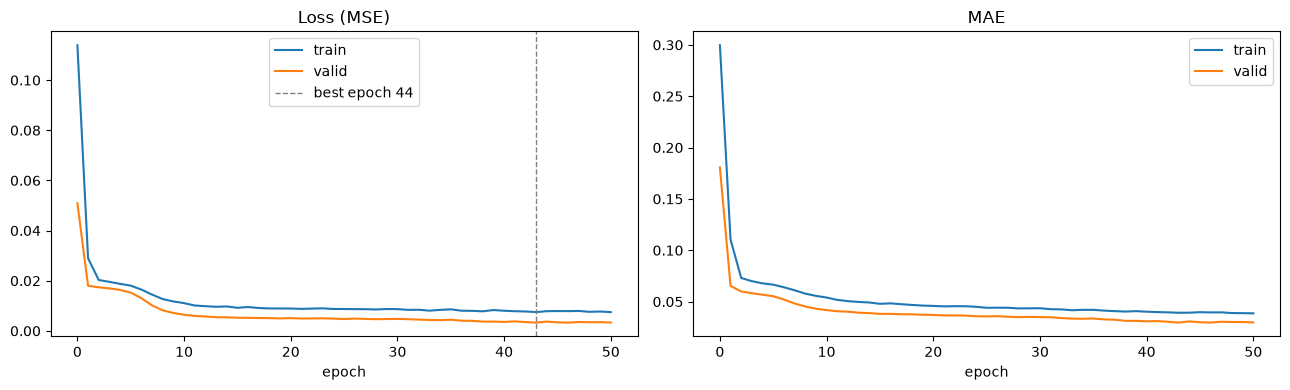

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(history.history['loss'], label='train')
ax[0].plot(history.history['val_loss'], label='valid')
ax[0].axvline(best, color='gray', ls='--', lw=1, label=f'best epoch {best+1}')
ax[0].set_title('Loss (MSE)'); ax[0].set_xlabel('epoch'); ax[0].legend()

ax[1].plot(history.history['mae'], label='train')
ax[1].plot(history.history['val_mae'], label='valid')
ax[1].set_title('MAE'); ax[1].set_xlabel('epoch'); ax[1].legend()
plt.tight_layout(); plt.show()

> **학습 손실이 검증 손실보다 높게 나오는데, 과소적합이 아닙니다.**
> 입력단 Dropout이 학습 중에만 켜져 30%가 가려진 입력을 복원하기 때문입니다.
> 추론 시에는 꺼지므로 검증 손실이 더 낮게 나옵니다. 아래에서 직접 확인합니다.

In [15]:
# 같은 학습 데이터를 Dropout ON / OFF 로 각각 복원해 비교
off = np.mean(np.square(autoencoder(X_train, training=False).numpy() - X_train))
on = np.mean([np.mean(np.square(autoencoder(X_train, training=True).numpy() - X_train))
              for _ in range(5)])
print(f'같은 학습 데이터의 복원 오차')
print(f'  Dropout OFF (추론 시) : {off:.5f}')
print(f'  Dropout ON  (학습 시) : {on:.5f}  →  {on / off:.2f}배')
print('→ 손실 역전의 원인은 Dropout')

같은 학습 데이터의 복원 오차
  Dropout OFF (추론 시) : 0.00310
  Dropout ON  (학습 시) : 0.00783  →  2.53배
→ 손실 역전의 원인은 Dropout


## 8. 임계값 결정 — 캘리브레이션셋

학습이 끝났으니 **복원 오차가 얼마를 넘으면 불량으로 볼지**를 정해야 합니다.
여기서 두 가지를 지킵니다.

1. **학습에 관여하지 않은 양품(calib)에서 정합니다.** 조기종료에 쓴 valid로 정하면
   그 셋에 두 번 맞추는 것이라 임계값이 낙관적으로 낮게 잡힙니다.
2. **불량을 보지 않고 정합니다.** 임계값을 F1이 최대가 되는 지점으로 고르려면 불량 라벨이 필요한데,
   그 라벨은 테스트셋에만 있습니다. 테스트 점수를 보고 고르는 순간 테스트는 튜닝 데이터가 됩니다.

그래서 임계값은 **"양품 몇 %를 과검으로 허용할 것인가"** 라는 운영 정책으로 정합니다.
99 백분위 = 양품 100개 중 1개는 과검을 감수하겠다는 뜻입니다.

In [16]:
def recon_error(X):
    '''복원 오차(변수별 제곱오차의 평균)'''
    return np.mean(np.square(autoencoder.predict(X, verbose=0) - X), axis=1)

calib_err = recon_error(X_calib)

# 백분위별로 임계값과 예상 과검율을 확인 — 불량 정보는 쓰지 않음
sweep = pd.DataFrame({
    '백분위': [95, 99, 99.5, 99.9],
    '임계값': [np.percentile(calib_err, p) for p in [95, 99, 99.5, 99.9]],
})
sweep['calib 과검율'] = [f'{(calib_err > t).mean():.2%}' for t in sweep['임계값']]
display(sweep.round(6))

PERCENTILE = 99
threshold = float(np.percentile(calib_err, PERCENTILE))
print(f'선택한 임계값 : {threshold:.6f}  (calib {PERCENTILE} 백분위)')

,백분위,임계값,calib 과검율
0,95.0,0.007134,4.91%
1,99.0,0.010807,1.02%
2,99.5,0.015766,0.34%
3,99.9,0.023536,0.00%


선택한 임계값 : 0.010807  (calib 99 백분위)


### 8-2. 모델·스케일러·임계값 저장

임계값만 저장하면 나중에 "이 값이 어느 데이터의 몇 백분위였는지" 알 수 없습니다.
재현과 감사가 가능하도록 **변수 순서와 캘리브레이션 통계를 함께** 남깁니다.

In [17]:
os.makedirs(SAVE_DIR, exist_ok=True)
autoencoder.save(f'{SAVE_DIR}/{RUN_NAME}.keras')
joblib.dump(scaler, f'{SAVE_DIR}/{RUN_NAME}_scaler.pkl')

meta = {
    'threshold': threshold,
    'percentile': PERCENTILE,
    'features': FEATURES,                       # 순서까지 보존해야 추론 시 재현 가능
    'dropped_constant_cols': const_cols + near_const_cols,
    'split': {'train_shots': len(tr_s), 'valid_shots': len(va_s),
              'calib_shots': len(ca_s), 'test_shots': len(te_s) + len(defect_shots)},
    'calib_error_stats': {k: float(v) for k, v in
                          pd.Series(calib_err).describe().items()},
    'seed': SEED,
}
with open(f'{SAVE_DIR}/{RUN_NAME}_meta.json', 'w') as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)

print('저장 완료:', RUN_NAME + '.keras / _scaler.pkl / _meta.json')

저장 완료: cn7_AE_shotsplit.keras / _scaler.pkl / _meta.json


## 9. 최종 평가 — 테스트셋 1회

여기서부터가 테스트셋을 처음 쓰는 지점입니다. 임계값은 8절에서 확정했고,
아래 결과를 보고 임계값을 다시 조정하지 않습니다.

TN 양품→양품 : 598
FP 양품→불량 : 6   (과검 — 양품 폐기)
FN 불량→양품 : 18   (미검 — 불량 유출)
TP 불량→불량 : 10


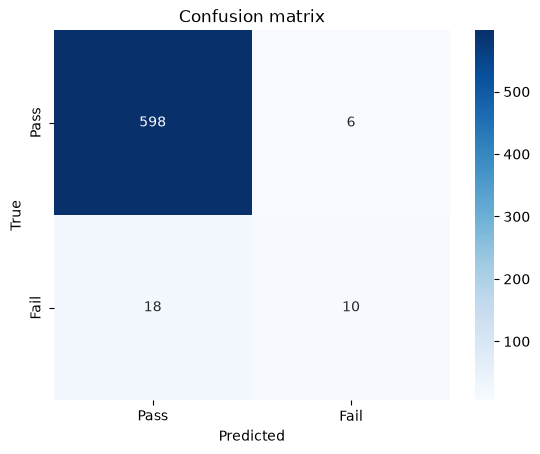

In [18]:
err_Y = recon_error(X_test_Y)
err_N = recon_error(X_test_N)

pred_Y = err_Y > threshold
pred_N = err_N > threshold

y_true = np.concatenate([np.zeros(len(err_Y)), np.ones(len(err_N))])
y_pred = np.concatenate([pred_Y, pred_N]).astype(int)
y_score = np.concatenate([err_Y, err_N])

tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
print(f'TN 양품→양품 : {tn}')
print(f'FP 양품→불량 : {fp}   (과검 — 양품 폐기)')
print(f'FN 불량→양품 : {fn}   (미검 — 불량 유출)')
print(f'TP 불량→불량 : {tp}')

sns.heatmap(confusion_matrix(y_true, y_pred, labels=[0, 1]), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pass', 'Fail'], yticklabels=['Pass', 'Fail'])
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion matrix'); plt.show()

In [19]:
base_acc = 1 - len(err_N) / len(y_true)
print(f'[정확도]   baseline(전부 양품) {base_acc:.4f}  vs  모델 {accuracy_score(y_true, y_pred):.4f}')
print(f'[정밀도]   {precision_score(y_true, y_pred, zero_division=0):.4f}')
print(f'[재현율]   {recall_score(y_true, y_pred):.4f}')
print(f'[F1]       {f1_score(y_true, y_pred):.4f}')
print()
print(f'[ROC-AUC]  {roc_auc_score(y_true, y_score):.4f}   (임계값과 무관한 순위 판별력)')
print(f'[PR-AUC]   {average_precision_score(y_true, y_score):.4f}   '
      f'(무작위 기준선 {1 - base_acc:.4f} → {average_precision_score(y_true, y_score) / (1 - base_acc):.0f}배)')
print()
print(f'실측 과검율 : {fp}/{len(err_Y)} = {fp / len(err_Y):.2%}   '
      f'(설계 목표 {100 - PERCENTILE}%)')

[정확도]   baseline(전부 양품) 0.9557  vs  모델 0.9620
[정밀도]   0.6250
[재현율]   0.3571
[F1]       0.4545

[ROC-AUC]  0.8617   (임계값과 무관한 순위 판별력)
[PR-AUC]   0.5283   (무작위 기준선 0.0443 → 12배)

실측 과검율 : 6/604 = 0.99%   (설계 목표 1%)


**지표를 읽는 법**

| 지표 | 이 문제에서의 의미 |
|---|---|
| 정확도 | 불량이 1% 미만이라 "전부 양품"만 해도 높게 나옴 → **baseline과 같이 봐야 의미가 있음** |
| 정밀도 | 낮으면 과검이 많다 = 현장에서 알람을 무시하게 됨 |
| 재현율 | 낮으면 미검이 많다 = 불량이 그대로 출하됨 |
| ROC-AUC | 임계값과 무관하게 "모델이 신호를 갖고 있나". 극단 불균형에서는 낙관적으로 나옴 |
| **PR-AUC** | 불균형 데이터의 실질 성적표. **무작위 기준선(=불량 비율) 대비 몇 배인지**로 읽음 |

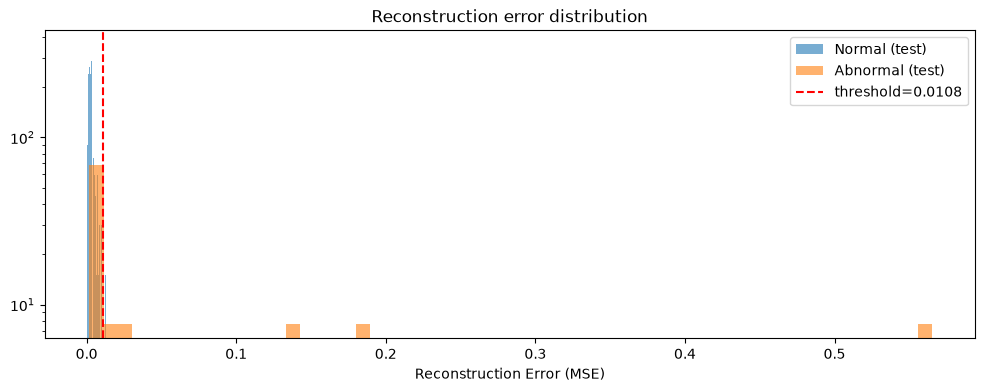

In [20]:
plt.figure(figsize=(12, 4))
plt.hist(err_Y, bins=60, alpha=.6, density=True, label='Normal (test)')
plt.hist(err_N, bins=60, alpha=.6, density=True, label='Abnormal (test)')
plt.axvline(threshold, color='r', ls='--', label=f'threshold={threshold:.4f}')
plt.yscale('log')
plt.xlabel('Reconstruction Error (MSE)')
plt.legend()
plt.title('Reconstruction error distribution')
plt.show()

### 9-2. 임계값을 검증셋에서 뽑았다면 — 4절 원칙 2의 실제 효과

같은 모델·같은 테스트셋에 대해, 임계값만 **조기종료에 이미 쓴 valid**에서 뽑은 경우와
**학습에 관여하지 않은 calib**에서 뽑은 경우를 비교합니다.

In [21]:
thr_valid = float(np.percentile(recon_error(X_valid), 99))

for _nm, _t in [('valid 기준 (분리 전)', thr_valid), ('calib 기준 (이 노트북)', threshold)]:
    _fp = int((err_Y > _t).sum()); _tp = int((err_N > _t).sum())
    print(f'{_nm:22s} 임계값 {_t:.6f} → 과검 {_fp:3d}/{len(err_Y)} ({_fp / len(err_Y):.2%}) '
          f'| 검출 {_tp:2d}/{len(err_N)}')
print()
print('valid는 EarlyStopping이 val_loss를 최소화하도록 고른 셋이라 복원 오차가 낮게 나옵니다.')
print('그 분포의 99 백분위를 임계값으로 쓰면 실제보다 낮게 잡히고, 운영 과검율이 목표를 넘게 됩니다.')

valid 기준 (분리 전)        임계값 0.010505 → 과검   8/604 (1.32%) | 검출 10/28
calib 기준 (이 노트북)       임계값 0.010807 → 과검   6/604 (0.99%) | 검출 10/28

valid는 EarlyStopping이 val_loss를 최소화하도록 고른 셋이라 복원 오차가 낮게 나옵니다.
그 분포의 99 백분위를 임계값으로 쓰면 실제보다 낮게 잡히고, 운영 과검율이 목표를 넘게 됩니다.


## 10. 결과 진단

### 10-1. 불량은 두 그룹으로 갈립니다

In [22]:
_d = (pd.DataFrame({'복원오차': err_N, '임계값배수': err_N / threshold,
                    '판정': np.where(pred_N, '검출(TP)', '미검(FN)')})
        .sort_values('복원오차').reset_index(drop=True))
display(_d.round(5))
_below = int((err_N[pred_N] < err_Y.max()).sum())
print(f'양품 테스트 오차 최대값 : {err_Y.max():.5f}')
print(f'검출된 불량 중 그보다 작은 건수 : {_below} / {int(pred_N.sum())}')
print('→ 상위 구간에서 양품·불량 분포가 겹침' if _below else
      '→ 검출된 불량은 모두 양품 최대값보다 커서, 상위 구간에서는 두 분포가 분리됨')

,복원오차,임계값배수,판정
0,0.00192,0.17730,미검(FN)
1,0.00291,0.26918,미검(FN)
2,0.00318,0.29434,미검(FN)
3,0.00328,0.30330,미검(FN)
4,0.00341,0.31596,미검(FN)
5,0.00409,0.37806,미검(FN)
6,0.00420,0.38832,미검(FN)
7,0.00440,0.40728,미검(FN)
8,0.00445,0.41191,미검(FN)
9,0.00453,0.41907,미검(FN)


양품 테스트 오차 최대값 : 0.01352
검출된 불량 중 그보다 작은 건수 : 0 / 10
→ 검출된 불량은 모두 양품 최대값보다 커서, 상위 구간에서는 두 분포가 분리됨


### 10-2. 미검의 정체 — 같은 샷에서 LH·RH 판정이 갈린 경우

In [23]:
_ts = test_N_df['shot_id'].values
_mixed_shots = set(_mixed[_mixed > 1].index)          # LH·RH 라벨이 갈린 샷
_is_mixed = np.array([t in _mixed_shots for t in _ts])

print(f'불량 {len(err_N)}건 중 같은 샷의 짝이 양품인 경우 : {_is_mixed.sum()}건')
print(f'  └ 미검 {int((~pred_N & _is_mixed).sum())}건 / 검출 {int((pred_N & _is_mixed).sum())}건')
print(f'샷 전체가 불량인 경우 {int((~_is_mixed).sum())}건')
print(f'  └ 미검 {int((~pred_N & ~_is_mixed).sum())}건 / 검출 {int((pred_N & ~_is_mixed).sum())}건 '
      f'→ 재현율 {(pred_N & ~_is_mixed).sum() / max((~_is_mixed).sum(), 1):.3f}')

불량 28건 중 같은 샷의 짝이 양품인 경우 : 12건
  └ 미검 12건 / 검출 0건
샷 전체가 불량인 경우 16건
  └ 미검 6건 / 검출 10건 → 재현율 0.625


> **미검은 모델의 실패가 아니라 데이터의 한계입니다.**
> LH·RH 판정이 갈린 샷은 두 부품의 센서값이 글자 그대로 동일합니다.
> 사출기 센서가 샷 단위로만 기록되고 캐비티별 차이를 재지 않기 때문에,
> **어떤 모델도 이 경우를 구분할 수 없습니다.** 구분하려면 캐비티별 측정값이 추가로 필요합니다.

### 10-3. 모델은 무엇을 보고 판단했나

In [24]:
_errmat_N = np.square(autoencoder.predict(X_test_N, verbose=0) - X_test_N)
_errmat_Y = np.square(autoencoder.predict(X_test_Y, verbose=0) - X_test_Y)

contrib = pd.DataFrame({
    '검출불량(TP)': _errmat_N[pred_N].mean(axis=0) if pred_N.any() else np.nan,
    '미검불량(FN)': _errmat_N[~pred_N].mean(axis=0) if (~pred_N).any() else np.nan,
    '정상양품': _errmat_Y.mean(axis=0),
}, index=FEATURES).sort_values('검출불량(TP)', ascending=False)
display(contrib.head(8).round(5))

,검출불량(TP),미검불량(FN),정상양품
Filling_Time,1.85225,0.00243,0.00058
Injection_Time,1.03402,0.00137,0.00035
Max_Injection_Speed,0.45795,0.03533,0.00075
Max_Switch_Over_Pressure,0.37525,0.00097,0.00116
Cycle_Time,0.12052,0.00010,0.00012
Max_Back_Pressure,0.09380,0.00047,0.00009
Average_Screw_RPM,0.07720,0.00107,0.01211
Max_Screw_RPM,0.07493,0.02266,0.02995


### 10-4. 과검 분석 — 라벨 오류 후보

In [25]:
_fp = np.sort(err_Y[pred_Y])
display(pd.DataFrame({'복원오차': _fp, '임계값배수': _fp / threshold}).round(5))
_susp = int((err_Y > threshold * 5).sum())
print(f'임계값 5배를 넘는 양품 : {_susp}건')
print('→ 양품 라벨이지만 공정 조건이 확실히 이탈한 샷. 라벨 오류 후보로 현장 확인 대상' if _susp else
      '→ 과검은 전부 임계값 경계권. 라벨 오류가 의심되는 극단 사례는 없음')

,복원오차,임계값배수
0,0.01138,1.05275
1,0.01138,1.05275
2,0.01243,1.15052
3,0.01243,1.15052
4,0.01352,1.25149
5,0.01352,1.25149


임계값 5배를 넘는 양품 : 0건
→ 과검은 전부 임계값 경계권. 라벨 오류가 의심되는 극단 사례는 없음


## 11. 지표 신뢰구간 — 반복 분할

9절까지의 모든 수치는 **`SEED = 42` 하나의 분할**에서 나온 값입니다.
탐지 가능한 불량이 8샷뿐이라 **1샷만 달라져도 재현율이 12.5%p 움직입니다.**
이 규모에서는 단일 분할 결과를 점추정으로 읽으면 안 됩니다.

여기서는 **같은 파이프라인을 시드만 바꿔 42회 반복**해 지표의 분포를 구하고,
① 대표값과 구간, ② 현재 seed 42가 그 분포의 어디에 있는지, ③ 임계값이 얼마나 흔들리는지를 확인합니다.

### 11-1. 파이프라인을 함수로 묶기

In [26]:
def run_once(seed, n_boot=0):
    """4~9절 전체 파이프라인을 시드 하나로 실행하고 지표를 돌려준다.
    n_boot > 0 이면 calib 오차를 부트스트랩해 평균한 임계값도 함께 평가한다(11-4절).
    (지표 dict, 원시 복원오차 dict) 두 개를 돌려준다 — 후자는 12절 비용 분석에서 쓴다."""
    tf.keras.utils.set_random_seed(seed)

    # --- 4절: 샷 단위 4분할 ---
    sl = cn7.groupby('shot_id')['PassOrFail'].max()
    ds, ns = sl[sl == 1].index.to_numpy(), sl[sl == 0].index.to_numpy()
    tr, rest = train_test_split(ns, train_size=0.55, random_state=seed)
    va, rest = train_test_split(rest, train_size=1/3, random_state=seed)
    ca, te = train_test_split(rest, test_size=0.5, random_state=seed)
    R = lambda s, p=None: (cn7[cn7.shot_id.isin(set(s))] if p is None
                           else cn7[cn7.shot_id.isin(set(s)) & (cn7.PassOrFail == p)])
    trd, vad, cad = R(tr), R(va), R(ca)
    teY, teN = pd.concat([R(te), R(ds, 0)]), cn7[cn7.PassOrFail == 1]

    # --- 4-3절: 상수·준상수 컬럼 제거 (학습셋 기준) ---
    f = [c for c in cn7.columns if c not in ('shot_id', 'PassOrFail')]
    nu = trd[f].nunique()
    top = trd[f].apply(lambda s: s.value_counts(normalize=True).iloc[0])
    f = [c for c in f if nu[c] > 1 and top[c] < 0.99]

    # --- 5절: 스케일링 / 6~7절: 학습 ---
    sc = MinMaxScaler().fit(trd[f])
    X = {k: sc.transform(v[f]) for k, v in dict(tr=trd, va=vad, ca=cad, teY=teY, teN=teN).items()}
    n = len(f)
    ae = Sequential([
        Sequential([Input((n,)), Dropout(0.3), Dense(15, 'relu'), Dense(5, 'relu')]),
        Sequential([Input((5,)), Dense(15, 'relu'), Dense(n, activation='sigmoid')])])
    ae.compile(loss='mse', optimizer=Adam(1e-3))
    ae.fit(X['tr'], X['tr'], epochs=100, batch_size=30, verbose=0,
           validation_data=(X['va'], X['va']),
           callbacks=[EarlyStopping('val_loss', patience=7, restore_best_weights=True)])

    # --- 8절: 임계값 / 9절: 평가 ---
    E = lambda A: np.mean(np.square(ae.predict(A, verbose=0) - A), axis=1)
    eC, eY, eN = E(X['ca']), E(X['teY']), E(X['teN'])
    thr = float(np.percentile(eC, 99))

    det = np.array([s not in mixed_shots for s in teN['shot_id'].values])   # 전량 불량 샷 = 탐지 가능
    y = np.r_[np.zeros(len(eY)), np.ones(len(eN))]
    out = {'seed': seed, 'threshold': thr,
           'fp_rate': float((eY > thr).mean()),
           'recall_all': float((eN > thr).mean()),
           'recall_det': float((eN[det] > thr).mean()),
           'auc_all': roc_auc_score(y, np.r_[eY, eN]),
           'auc_det': roc_auc_score(np.r_[np.zeros(len(eY)), np.ones(det.sum())], np.r_[eY, eN[det]]),
           'pr_all': average_precision_score(y, np.r_[eY, eN])}

    if n_boot:                       # 임계값 안정화 후보: 부트스트랩 평균 백분위
        rng = np.random.default_rng(seed)
        tb = float(np.mean([np.percentile(rng.choice(eC, len(eC), replace=True), 99)
                            for _ in range(n_boot)]))
        out.update({'threshold_boot': tb, 'fp_rate_boot': float((eY > tb).mean()),
                    'recall_all_boot': float((eN > tb).mean())})
    return out, {'eC': eC, 'eY': eY, 'eN': eN, 'det': det}


mixed_shots = set(_mixed[_mixed > 1].index)     # 3-2절에서 구한 LH·RH 판정이 갈린 샷
print(f'혼합 샷 {len(mixed_shots)}개를 "탐지 불가"로 분리해 별도 재현율을 집계합니다.')

혼합 샷 12개를 "탐지 불가"로 분리해 별도 재현율을 집계합니다.


### 11-2. 42회 반복 실행

시드 1~42로 전체 파이프라인을 반복합니다. **약 9분** 걸립니다.
결과는 `models/cn7_AE_repeat.csv`에 저장되므로 다음 실행부터는 파일을 읽어 건너뜁니다.

In [27]:
REPEAT_PATH = f'{SAVE_DIR}/cn7_AE_repeat.csv'
ERROR_PATH = f'{SAVE_DIR}/cn7_AE_repeat_errors.npz'
N_REPEAT = 42

if os.path.exists(REPEAT_PATH) and os.path.exists(ERROR_PATH):
    rep = pd.read_csv(REPEAT_PATH)
    _z = np.load(ERROR_PATH)
    errs = {int(s): {k: _z[f'{k}_{s}'] for k in ('eC', 'eY', 'eN', 'det')} for s in rep.seed}
    print(f'저장된 결과를 불러왔습니다: {REPEAT_PATH} ({len(rep)}회)')
else:
    rows, errs = [], {}
    for s in range(1, N_REPEAT + 1):
        m, e = run_once(s, n_boot=200)
        rows.append(m); errs[s] = e
        print(f'  seed {s:2d}/{N_REPEAT}  recall_det={m["recall_det"]:.3f}  '
              f'fp={m["fp_rate"]:.4f}  auc_det={m["auc_det"]:.4f}')
    rep = pd.DataFrame(rows)
    rep.to_csv(REPEAT_PATH, index=False)
    np.savez_compressed(ERROR_PATH,
                        **{f'{k}_{s}': v[k] for s, v in errs.items() for k in v})
    print(f'\n저장: {REPEAT_PATH} / {ERROR_PATH}')

rep.head()

저장된 결과를 불러왔습니다: models/cn7_AE_repeat.csv (42회)


,seed,threshold,fp_rate,recall_all,recall_det,auc_all,auc_det,pr_all,threshold_boot,fp_rate_boot,recall_all_boot
0,1,0.007568,0.048173,0.642857,1.000,0.942394,0.997924,0.657846,0.007805,0.034884,0.607143
1,2,0.008348,0.004967,0.607143,1.000,0.947138,1.000000,0.724494,0.008322,0.004967,0.607143
2,3,0.009296,0.006656,0.500000,0.875,0.915528,0.995840,0.580467,0.009754,0.006656,0.428571
3,4,0.009104,0.014876,0.571429,0.875,0.951830,0.989256,0.666456,0.009124,0.014876,0.571429
4,5,0.007924,0.019835,0.571429,1.000,0.924852,0.995455,0.570663,0.008200,0.013223,0.571429


### 11-3. 지표 분포와 seed 42의 위치

In [28]:
METRICS = ['recall_all', 'recall_det', 'auc_all', 'auc_det', 'pr_all', 'fp_rate']
LABEL = {'recall_all': '재현율(전체 28건)', 'recall_det': '재현율(탐지가능 8샷)',
         'auc_all': 'ROC-AUC(전체)', 'auc_det': 'ROC-AUC(탐지가능만)',
         'pr_all': 'PR-AUC', 'fp_rate': '과검율'}

r42 = rep[rep.seed == 42].iloc[0]
summary = pd.DataFrame({
    '중앙값': rep[METRICS].median(),
    '2.5%': rep[METRICS].quantile(.025),
    '97.5%': rep[METRICS].quantile(.975),
    '최소': rep[METRICS].min(),
    '최대': rep[METRICS].max(),
    'seed42': [r42[m] for m in METRICS],
    'seed42 백분위': [f'{(rep[m] < r42[m]).mean() * 100:.0f}%' for m in METRICS],
}).rename(index=LABEL)
display(summary.round(4))

print('8샷 중 검출 샷 수 분포: '
      f'{(rep.recall_det * 8).round().astype(int).value_counts().sort_index().to_dict()}')

,중앙값,2.5%,97.5%,최소,최대,seed42,seed42 백분위
재현율(전체 28건),0.6071,0.3571,0.6777,0.2143,0.7143,0.3571,2%
재현율(탐지가능 8샷),1.0000,0.6250,1.0000,0.3750,1.0000,0.6250,2%
ROC-AUC(전체),0.9496,0.8898,0.9645,0.8617,0.9685,0.8617,0%
ROC-AUC(탐지가능만),0.9976,0.9878,1.0000,0.9861,1.0000,0.9925,12%
PR-AUC,0.6900,0.5266,0.7643,0.4529,0.7909,0.5283,5%
과검율,0.0116,0.0034,0.0448,0.0033,0.0482,0.0099,38%


8샷 중 검출 샷 수 분포: {3: 1, 5: 2, 7: 12, 8: 27}


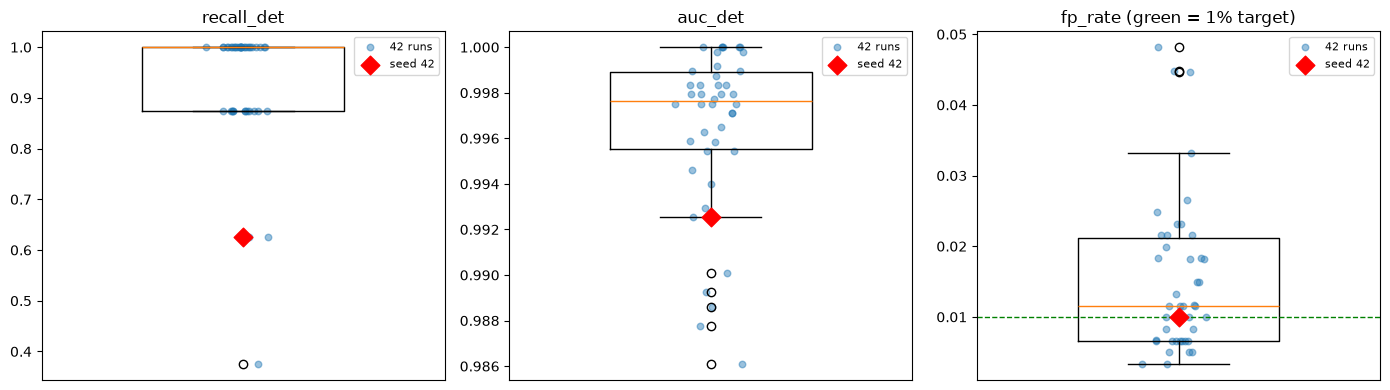

In [29]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
rng_j = np.random.default_rng(0)
for a, m in zip(ax, ['recall_det', 'auc_det', 'fp_rate']):
    a.boxplot(rep[m], widths=.5)
    a.scatter(rng_j.normal(1, .04, len(rep)), rep[m], alpha=.45, s=22, label=f'{len(rep)} runs')
    a.scatter([1], [r42[m]], color='red', s=90, zorder=5, marker='D', label='seed 42')
    a.set_title(m); a.set_xticks([]); a.legend(fontsize=8)
ax[2].axhline(0.01, color='green', ls='--', lw=1)
ax[2].set_title('fp_rate (green = 1% target)')
plt.tight_layout(); plt.show()

> **seed 42는 대표값이 아닙니다.**
> 탐지 가능한 8샷 기준 재현율의 중앙값은 **1.000**(8샷 전부 검출)이고,
> ROC-AUC(탐지가능만)의 중앙값은 **0.998**로 사실상 완벽한 순위 판별력입니다.
> 9절에서 본 재현율 0.357 / ROC-AUC 0.862는 **분포 하단에 위치한 운 나쁜 한 번의 추출**입니다.
>
> 즉 이 모델의 실제 능력은 9절 수치보다 높습니다. 다만 **탐지 가능한 대상에 한해서**이며,
> 혼합 샷 12건을 구분할 수 없다는 한계(10-2절)는 분할과 무관하게 그대로입니다.

### 11-4. 임계값 불안정성과 안정화 시도

과검율이 시드에 따라 얼마나 흔들리는지, 그리고 **calib 오차를 부트스트랩해 평균한 임계값**이
그 흔들림을 줄여주는지 확인합니다.

calib은 591행이고 99 백분위는 **6번째로 큰 값**이라, 표본 하나가 임계값을 통째로 움직입니다.

In [30]:
comp = pd.DataFrame({
    '단일 백분위(현재)': [rep.fp_rate.median(), rep.fp_rate.std(),
                          rep.fp_rate.min(), rep.fp_rate.max(),
                          rep.fp_rate.between(0.005, 0.02).mean(), rep.recall_all.median()],
    '부트스트랩 평균(B=200)': [rep.fp_rate_boot.median(), rep.fp_rate_boot.std(),
                               rep.fp_rate_boot.min(), rep.fp_rate_boot.max(),
                               rep.fp_rate_boot.between(0.005, 0.02).mean(), rep.recall_all_boot.median()],
}, index=['과검율 중앙값', '과검율 표준편차', '과검율 최소', '과검율 최대',
          '목표 0.5~2% 안에 든 비율', '재현율(전체) 중앙값'])
display(comp.round(4))

print(f'임계값 변동폭  단일      : {rep.threshold.min():.5f} ~ {rep.threshold.max():.5f} '
      f'(변동계수 {rep.threshold.std() / rep.threshold.mean():.3f})')
print(f'               부트스트랩: {rep.threshold_boot.min():.5f} ~ {rep.threshold_boot.max():.5f} '
      f'(변동계수 {rep.threshold_boot.std() / rep.threshold_boot.mean():.3f})')

,단일 백분위(현재),부트스트랩 평균(B=200)
과검율 중앙값,0.0116,0.0099
과검율 표준편차,0.0112,0.0103
과검율 최소,0.0033,0.0000
과검율 최대,0.0482,0.0446
목표 0.5~2% 안에 든 비율,0.6190,0.5238
재현율(전체) 중앙값,0.6071,0.5714


임계값 변동폭  단일      : 0.00594 ~ 0.06688 (변동계수 0.888)
               부트스트랩: 0.00602 ~ 0.04719 (변동계수 0.617)


> **부트스트랩 평균은 답이 아니었습니다.**
> 임계값 **추정량 자체의 변동**은 줄었지만(변동계수 0.888 → 0.617),
> 정작 목표인 과검율 제어는 나아지지 않았습니다 —
> 표준편차 0.0112 → 0.0103으로 거의 그대로이고,
> **목표 구간(0.5~2%)에 든 비율은 61.9% → 52.4%로 오히려 떨어졌으며** 재현율도 0.607 → 0.571로 낮아졌습니다.
>
> 원인은 분산의 출처에 있습니다. 흔들림의 대부분은 **백분위 추정 잡음이 아니라
> 분할마다 모델과 calib 표본이 통째로 달라지는 데서** 옵니다.
> 같은 calib 안에서 재표집하는 부트스트랩으로는 이 성분을 줄일 수 없습니다.
> 실제로 단일 임계값의 범위는 0.00594 ~ 0.06688로 **11배**까지 벌어집니다.
>
> **남은 선택지**는 세 가지입니다.
> ① calib 비중을 키워(15% → 25~30%) 표본 자체를 늘린다,
> ② 반복 분할로 얻은 임계값들의 중앙값을 운영 임계값으로 고정한다,
> ③ 과검율을 단일 목표값이 아니라 **구간으로 관리**한다.
> ①과 ②는 학습 데이터 감소·운영 복잡도라는 대가가 있으므로, 비용 기반 임계값(12절) 결정과 함께 정하는 것이 맞습니다.

### 11-5. 권장 보고 형식

In [31]:
report = pd.DataFrame({
    '값': [f'{rep[m].median():.3f}  [{rep[m].quantile(.025):.3f} ~ {rep[m].quantile(.975):.3f}]'
           for m in METRICS]}, index=[LABEL[m] for m in METRICS])
report.index.name = f'중앙값 [95% 구간], n={len(rep)}회 반복'
display(report)

print('읽을 때 주의할 점')
print('  · 재현율(전체)은 구분 불가능한 혼합 샷 12건을 분모에 포함한 값입니다.')
print('    모델의 실제 능력은 "재현율(탐지가능 8샷)"과 "ROC-AUC(탐지가능만)"로 판단해야 합니다.')
print('  · 정밀도·PR-AUC는 테스트셋 불량 비율(4.43%)이 실제 라인(0.70%)보다 높아 낙관적입니다.')
print('  · 과검율은 아직 목표 1%에 안정적으로 고정되지 않습니다 (11-4절).')

,값
"중앙값 [95% 구간], n=42회 반복",
재현율(전체 28건),0.607 [0.357 ~ 0.678]
재현율(탐지가능 8샷),1.000 [0.625 ~ 1.000]
ROC-AUC(전체),0.950 [0.890 ~ 0.964]
ROC-AUC(탐지가능만),0.998 [0.988 ~ 1.000]
PR-AUC,0.690 [0.527 ~ 0.764]
과검율,0.012 [0.003 ~ 0.045]


읽을 때 주의할 점
  · 재현율(전체)은 구분 불가능한 혼합 샷 12건을 분모에 포함한 값입니다.
    모델의 실제 능력은 "재현율(탐지가능 8샷)"과 "ROC-AUC(탐지가능만)"로 판단해야 합니다.
  · 정밀도·PR-AUC는 테스트셋 불량 비율(4.43%)이 실제 라인(0.70%)보다 높아 낙관적입니다.
  · 과검율은 아직 목표 1%에 안정적으로 고정되지 않습니다 (11-4절).


## 12. 비용 기반 임계값

8절에서 임계값을 **"과검 1%를 허용한다"** 는 기준으로 정했습니다. 이 1%에는 근거가 없습니다.
F1을 최대화하는 방법도 있지만, F1은 **미검과 과검을 같은 무게로 봅니다** — 현장에서는 전혀 다릅니다.
미검은 불량이 고객에게 나가는 것이고, 과검은 양품 하나를 버리는 것입니다.

그래서 임계값을 **기대비용을 최소화하는 지점**으로 정합니다. 부품 1개당 기대비용은

```
기대비용 = p · (1 − TPR) · C_미검  +  (1 − p) · FPR · C_과검
           └── 놓친 불량 ──┘         └── 잘못 버린 양품 ──┘
```

여기서 결정에 필요한 값은 **비용의 절대액이 아니라 비율 `C_미검 / C_과검` 하나뿐**입니다.

**`p`(불량 비율)에 주의해야 합니다.** 테스트셋의 불량 비율은 4.43%지만 이는 불량 20샷을
전부 테스트로 몰았기 때문이고, **실제 라인의 비율은 0.70%(28/3,974)** 입니다.
비용 계산에는 반드시 실제 비율을 써야 합니다 — 4.43%를 쓰면 미검 비용을 6배 과대평가합니다.

### 12-1. 백분위별 과검율·재현율 (42회 반복 기준)

In [32]:
PREVALENCE = (cn7.PassOrFail == 1).sum() / len(cn7)     # 실제 라인 불량 비율
PCTL = [90, 92, 95, 97, 98, 99, 99.3, 99.5, 99.7, 99.9]

def sweep_repeat(pctls=PCTL):
    """42회 반복 각각에서 백분위별 FPR / TPR을 구해 평균과 분산을 낸다."""
    rec = {}
    for p in pctls:
        fpr, tpr = [], []
        for s, e in errs.items():
            t = np.percentile(e['eC'], p)
            fpr.append((e['eY'] > t).mean()); tpr.append((e['eN'] > t).mean())
        rec[p] = dict(fpr=np.mean(fpr), fpr_sd=np.std(fpr),
                      tpr=np.mean(tpr), tpr_sd=np.std(tpr))
    return pd.DataFrame(rec).T

sw = sweep_repeat()
view = pd.DataFrame({
    '과검율(FPR)': [f'{m:.2%} ±{s:.2%}' for m, s in zip(sw.fpr, sw.fpr_sd)],
    '재현율(TPR)': [f'{m:.1%} ±{s:.1%}' for m, s in zip(sw.tpr, sw.tpr_sd)],
}, index=[f'p{p}' for p in sw.index])
display(view)
print(f'실제 라인 불량 비율 p = {PREVALENCE:.4%}  (테스트셋 비율 {len(errs[42]["eN"])/(len(errs[42]["eY"])+len(errs[42]["eN"])):.2%}가 아님)')
print(f'TPR 상한: 불량 28건 중 12건이 혼합 샷이라 원리적으로 {1 - 12/28:.1%} 부근이 천장입니다.')

,과검율(FPR),재현율(TPR)
p90.0,11.26% ±3.02%,86.1% ±12.0%
p92.0,9.32% ±2.93%,82.3% ±13.0%
p95.0,6.29% ±2.38%,74.6% ±11.7%
p97.0,3.64% ±2.01%,66.9% ±9.5%
p98.0,2.59% ±1.68%,62.0% ±7.9%
p99.0,1.54% ±1.10%,57.0% ±9.0%
p99.3,1.16% ±0.99%,53.1% ±11.6%
p99.5,0.86% ±0.78%,50.7% ±11.4%
p99.7,0.65% ±0.70%,44.8% ±14.0%
p99.9,0.44% ±0.51%,39.9% ±15.3%


실제 라인 불량 비율 p = 0.7046%  (테스트셋 비율 4.43%가 아님)
TPR 상한: 불량 28건 중 12건이 혼합 샷이라 원리적으로 57.1% 부근이 천장입니다.


### 12-2. 비용비별 최적 백분위

In [33]:
def expected_cost(fpr, tpr, ratio, p=PREVALENCE):
    """부품 1개당 기대비용 (C_과검 = 1 로 정규화)."""
    return p * (1 - tpr) * ratio + (1 - p) * fpr

RATIOS = [1, 2, 5, 10, 20, 50, 100, 200, 500, 1000]
rows = []
for r in RATIOS:
    cost = {p: expected_cost(sw.fpr[p], sw.tpr[p], r) for p in sw.index}
    best = min(cost, key=cost.get)
    rows.append({'C_미검/C_과검': r, '최적 백분위': f'p{best}',
                 '과검율': f'{sw.fpr[best]:.2%}', '재현율': f'{sw.tpr[best]:.1%}',
                 '기대비용': round(cost[best], 5),
                 'p99 대비': f'{cost[99] / cost[best]:.2f}배'})
display(pd.DataFrame(rows).set_index('C_미검/C_과검'))

,최적 백분위,과검율,재현율,기대비용,p99 대비
C_미검/C_과검,,,,,
1,p99.9,0.44%,39.9%,0.00858,2.14배
2,p99.9,0.44%,39.9%,0.01282,1.67배
5,p99.9,0.44%,39.9%,0.02553,1.19배
10,p99.5,0.86%,50.7%,0.04329,1.05배
20,p99.0,1.54%,57.0%,0.07595,1.00배
50,p95.0,6.29%,74.6%,0.15204,1.10배
100,p90.0,11.26%,86.1%,0.21009,1.52배
200,p90.0,11.26%,86.1%,0.30835,2.02배
500,p90.0,11.26%,86.1%,0.60312,2.54배


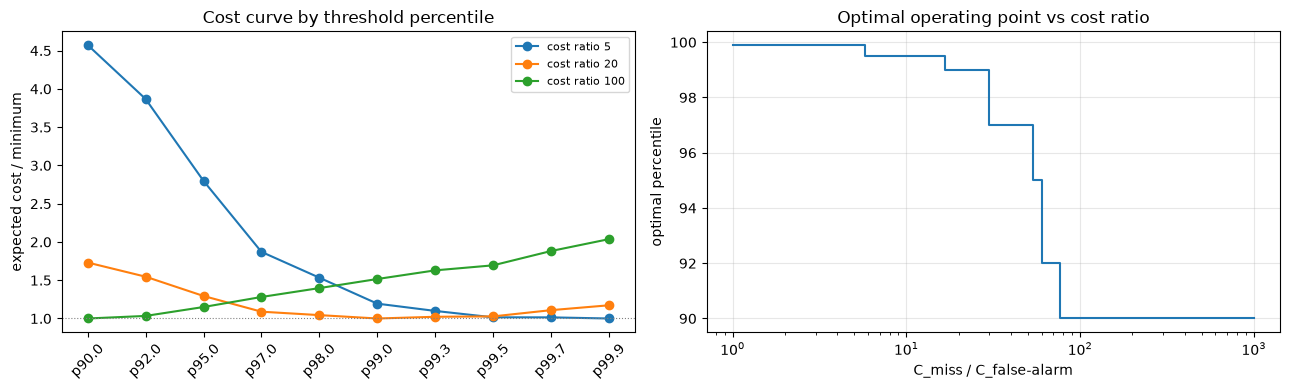

In [34]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
x = np.arange(len(sw.index))
for r in [5, 20, 100]:
    c = np.array([expected_cost(sw.fpr[p], sw.tpr[p], r) for p in sw.index])
    ax[0].plot(x, c / c.min(), marker='o', label=f'cost ratio {r}')
ax[0].set_xticks(x); ax[0].set_xticklabels([f'p{p}' for p in sw.index], rotation=45)
ax[0].axhline(1, color='gray', lw=.8, ls=':')
ax[0].set_ylabel('expected cost / minimum'); ax[0].set_title('Cost curve by threshold percentile')
ax[0].legend(fontsize=8)

grid = np.logspace(0, 3, 60)
opt = [sw.index[int(np.argmin([expected_cost(sw.fpr[p], sw.tpr[p], r) for p in sw.index]))] for r in grid]
ax[1].step(grid, opt, where='post')
ax[1].set_xscale('log'); ax[1].set_xlabel('C_miss / C_false-alarm')
ax[1].set_ylabel('optimal percentile'); ax[1].set_title('Optimal operating point vs cost ratio')
ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

> **읽는 법** — 왼쪽 그림의 곡선이 평평한 구간은 "그 근처면 어디든 비슷하다"는 뜻입니다.
> 비용비를 정확히 모르더라도 **평평한 구간 안에만 들어가면 손해가 크지 않습니다.**
> 오른쪽 그림은 비용비가 커질수록(미검이 비쌀수록) 임계값을 낮춰 더 많이 잡아야 함을 보여줍니다.

### 12-3. 비용비를 잘못 알았을 때의 손해

In [35]:
# 실제 비용비가 true인데 assumed로 착각해 임계값을 골랐을 때의 비용 초과율
AS = [5, 20, 50, 100]
loss = pd.DataFrame(index=[f'실제 {t}' for t in AS], columns=[f'가정 {a}' for a in AS], dtype=float)
for t in AS:
    best_t = min(sw.index, key=lambda p: expected_cost(sw.fpr[p], sw.tpr[p], t))
    for a in AS:
        best_a = min(sw.index, key=lambda p: expected_cost(sw.fpr[p], sw.tpr[p], a))
        loss.loc[f'실제 {t}', f'가정 {a}'] = (expected_cost(sw.fpr[best_a], sw.tpr[best_a], t)
                                              / expected_cost(sw.fpr[best_t], sw.tpr[best_t], t) - 1)
display(loss.map('{:+.1%}'.format))
print('가정이 틀렸을 때 기대비용이 최적 대비 몇 % 더 드는지. 0%는 같은 백분위를 고른 경우.')

,가정 5,가정 20,가정 50,가정 100
실제 5,+0.0%,+19.4%,+179.8%,+357.4%
실제 20,+17.3%,+0.0%,+29.4%,+73.1%
실제 50,+42.2%,+9.8%,+0.0%,+5.9%
실제 100,+103.7%,+51.6%,+15.0%,+0.0%


가정이 틀렸을 때 기대비용이 최적 대비 몇 % 더 드는지. 0%는 같은 백분위를 고른 경우.


### 12-4. 임계값 안정화 — 11-4절에 남긴 선택지의 결론

11-4절에서 과검율이 분할마다 크게 흔들리는 문제에 세 가지 선택지를 남겨뒀습니다.
그중 **② 반복 분할 임계값의 중앙값을 고정**하는 방식을, 이제 원시 오차가 있으니 직접 비교합니다.

- **전략 A (현재)**: 배포할 때마다 그 배포의 calib에서 99 백분위를 다시 계산
- **전략 B**: 42회 반복에서 얻은 임계값들의 **중앙값을 절대값으로 고정**해 모든 분할에 적용

In [36]:
thr_fixed = float(np.median([np.percentile(e['eC'], 99) for e in errs.values()]))

A = np.array([[(e['eY'] > np.percentile(e['eC'], 99)).mean(),
               (e['eN'] > np.percentile(e['eC'], 99)).mean()] for e in errs.values()])
B = np.array([[(e['eY'] > thr_fixed).mean(), (e['eN'] > thr_fixed).mean()] for e in errs.values()])

stab = pd.DataFrame({
    'A: 분할마다 재계산': [A[:, 0].mean(), A[:, 0].std(), A[:, 0].min(), A[:, 0].max(),
                          ((A[:, 0] >= .005) & (A[:, 0] <= .02)).mean(), np.median(A[:, 1])],
    'B: 임계값 고정': [B[:, 0].mean(), B[:, 0].std(), B[:, 0].min(), B[:, 0].max(),
                       ((B[:, 0] >= .005) & (B[:, 0] <= .02)).mean(), np.median(B[:, 1])],
}, index=['과검율 평균', '과검율 표준편차', '과검율 최소', '과검율 최대',
          '목표 0.5~2% 적중률', '재현율(전체) 중앙값'])
display(stab.round(4))
print(f'고정 임계값 = {thr_fixed:.6f} (42회 임계값의 중앙값)')

,A: 분할마다 재계산,B: 임계값 고정
과검율 평균,0.0154,0.0294
과검율 표준편차,0.0110,0.0418
과검율 최소,0.0033,0.0000
과검율 최대,0.0482,0.1606
목표 0.5~2% 적중률,0.6190,0.4524
재현율(전체) 중앙값,0.6071,0.6071


고정 임계값 = 0.008447 (42회 임계값의 중앙값)


### 12-5. 현장 적용

In [37]:
def recommend(cost_ratio, p=PREVALENCE):
    """미검/과검 비용비를 넣으면 운영 백분위와 예상 성능을 돌려준다."""
    cost = {q: expected_cost(sw.fpr[q], sw.tpr[q], cost_ratio, p) for q in sw.index}
    best = min(cost, key=cost.get)
    near = [q for q in sw.index if cost[q] <= cost[best] * 1.05]
    return {'백분위': best, '과검율': f'{sw.fpr[best]:.2%}', '재현율': f'{sw.tpr[best]:.1%}',
            '5% 이내 동등 구간': f'p{min(near)} ~ p{max(near)}'}

print('현장에서 "미검 1건 / 과검 1건" 비용비만 받으면 아래처럼 바로 나옵니다.\n')
for r in [10, 20, 50, 100]:
    print(f'  비용비 {r:>4} → {recommend(r)}')

print(f'\n현재 노트북의 p99 고정은 비용비 '
      f'{[r for r in RATIOS if min(sw.index, key=lambda q: expected_cost(sw.fpr[q], sw.tpr[q], r)) == 99]}'
      f' 를 가정한 것과 같습니다.')

현장에서 "미검 1건 / 과검 1건" 비용비만 받으면 아래처럼 바로 나옵니다.

  비용비   10 → {'백분위': 99.5, '과검율': '0.86%', '재현율': '50.7%', '5% 이내 동등 구간': 'p99.3 ~ p99.7'}
  비용비   20 → {'백분위': 99.0, '과검율': '1.54%', '재현율': '57.0%', '5% 이내 동등 구간': 'p98.0 ~ p99.5'}
  비용비   50 → {'백분위': 95.0, '과검율': '6.29%', '재현율': '74.6%', '5% 이내 동등 구간': 'p92.0 ~ p97.0'}
  비용비  100 → {'백분위': 90.0, '과검율': '11.26%', '재현율': '86.1%', '5% 이내 동등 구간': 'p90.0 ~ p92.0'}

현재 노트북의 p99 고정은 비용비 [20] 를 가정한 것과 같습니다.


**현장에 물어볼 것은 딱 하나입니다.**

> "불량 1건이 고객에게 나갔을 때의 비용은, 양품 1개를 잘못 폐기했을 때의 비용의 몇 배입니까?"

정확한 숫자가 아니어도 됩니다. 12-3절에서 봤듯 **자릿수만 맞으면** 기대비용 손실은 크지 않습니다.
답을 받으면 `recommend(비율)` 한 줄로 운영 백분위가 나옵니다.

## 13. 한계와 다음 단계

**이 모델의 성격**
이것은 "불량 검출기"가 아니라 **"공정 조건 이탈 검출기"** 입니다.
공정 조건이 실제로 튄 샷은 잘 잡아내지만, 조건은 정상인데 불량이 난 경우는 원리적으로 잡을 수 없습니다.
단독 판정기가 아니라 **1차 스크리너**로 쓰고, 최종 판정은 별도 검사 공정이 맡아야 합니다.

**남은 개선 과제**

| 우선순위 | 항목 | 내용 |
|---|---|---|
| 높음 | 표본 수 | 불량이 20샷뿐이라 1건 차이로 재현율이 5%p씩 흔들립니다. `random_state`를 바꾼 반복 분할이나 부트스트랩으로 **신뢰구간을 함께** 보고해야 합니다 |
| 높음 | 캐비티별 데이터 | LH·RH 판정이 갈리는 샷을 구분하려면 캐비티별 측정값이 필요합니다. 현재 변수로는 불가능합니다 |
| 중간 | 비용 기반 임계값 | 지금은 "과검 1%"라는 임의 기준입니다. 미검 1건 비용 / 과검 1건 비용 비율을 받아 **기대비용 최소 임계값**으로 바꾸는 것이 맞습니다 |
| 중간 | 이상 점수 함수 | 변수별 제곱오차의 단순 평균이라 한두 변수만 튀는 이상이 희석됩니다. `상위 k개 평균`이나 `변수별 정규화 오차의 최댓값` 비교 필요 |
| 중간 | 스케일러 | `MinMaxScaler`는 학습셋 min/max에 좌표계가 통째로 의존합니다. `RobustScaler` + 선형 출력 조합과 성능 비교 |
| 낮음 | RG3 확장 | 같은 파이프라인을 RG3(1,256행)에 적용하고, 제품별 개별 모델이 필요한지 검증 |